# Week 4 — Driving the hand to a target

**Task.** Command the 2-D brain stimulation `u(t) ∈ [0,1]²` so the simulated hand reaches a target `(x, y)`, using only the official interface: the neural observations `bmi._brain.measure()` (16-D, very noisy), the current hand position `bmi.hand_pos`, and `bmi.next_state(u)`.

**Plant chain.**
`u → brain (LTI, per-trial random) → 16-D neural → ANN decoder → (x1,x2) → muscle head (nonlinear, stateful) → 4 muscles → 2-link arm → hand`.

**What we worked out (see lab notes):**
- The muscle head selects a muscle by the **frequency of `x1`** and powers it by the **`x2` "power" channel**.
- `x2` sits at a large **positive DC offset (~+1.8)** that already exceeds the power threshold, so **power is "free"** — we don't need a power tone, just a select tone (and we avoid making `x2` dip).
- Shoulder is driven by muscles 0/1, elbow by muscles 2/3 → **control decouples into two IK joint-servos**.
- The select **frequencies + joint map are brain-invariant** (calibrate once, offline); per-brain gain varies, handled by feedback.
- The plant is **very noisy/stochastic** (single `measure()` noise ≈ 2.6, averaged ×100 → ≈0.25), so the loop must be closed and evaluation must be multi-seed.

**Two versions (this notebook builds V1):**
- **V1 — hand feedback**: joint estimate from the measured `current_pos`.
- **V2 — neural-observer only**: joint estimate reconstructed from neural obs (no hand feedback). Built on the same servo.

All control logic lives in [`hand_control.py`](hand_control.py); the plant interface is the real `BMI_and_Hand` (needs the GG4 wheel + torch).

In [1]:
import sys, time
sys.path.insert(0, "../week_3")
import numpy as np
import matplotlib.pyplot as plt
from GG4 import Brain
from BMI_and_Hand import BMI_and_Hand
import importlib, hand_control as hc
importlib.reload(hc)

# per-trial plant factory (each seed = a different random brain; the ANN+arm are fixed)
def plant(seed=0):
    return BMI_and_Hand(Brain(random_seed=seed))

print("plant ready — input_dim =", plant(0)._brain.input_dim, ", neural dim =", len(plant(0)._brain.measure()))

plant ready — input_dim = 2 , neural dim = 16


## 1. Offline calibration — discover the primitives

We scan the select-frequency on a fresh plant; at each frequency a short two-tone burst is applied and the **steady joint angular velocity** is measured. The four muscle filters show up as four peaks — two on the shoulder, two on the elbow — giving the brain-invariant `(frequency → joint, direction)` map. *(This is the one place we read the true joint angles, for offline structure discovery only; the controller online uses `hand_pos` + IK.)*

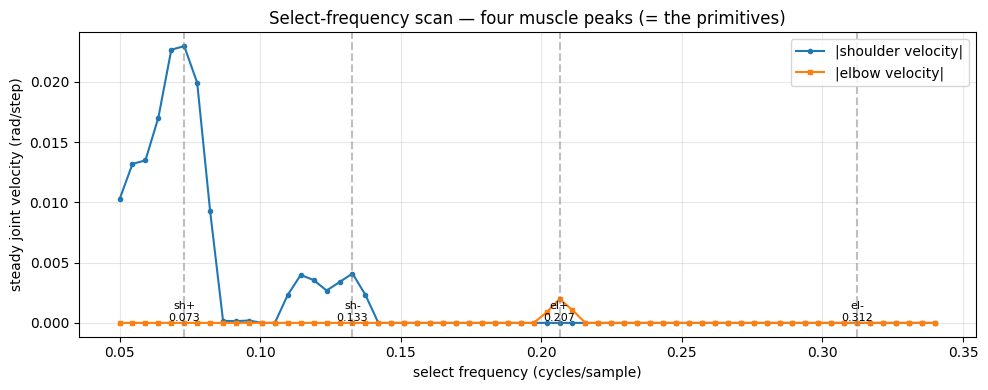

discovered primitives:
  f=0.073  shoulder +
  f=0.133  shoulder -
  f=0.207  elbow    +
  f=0.312  elbow    -


In [2]:
prims, rows = hc.calibrate_frequencies(lambda: plant(0), f_lo=0.05, f_hi=0.34, n_scan=64)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rows[:, 0], np.abs(rows[:, 1]), "-o", ms=3, label="|shoulder velocity|")
ax.plot(rows[:, 0], np.abs(rows[:, 2]), "-s", ms=3, label="|elbow velocity|")
for p in prims:
    jn = "sh" if p["joint"] == 0 else "el"
    ax.axvline(p["f"], ls="--", c="gray", alpha=0.5)
    ax.annotate(f"{jn}{'+' if p['sign']>0 else '-'}\n{p['f']:.3f}", (p["f"], 0),
                ha="center", va="bottom", fontsize=8)
ax.set(xlabel="select frequency (cycles/sample)", ylabel="steady joint velocity (rad/step)",
       title="Select-frequency scan — four muscle peaks (= the primitives)")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("discovered primitives:")
for p in prims:
    print(f"  f={p['f']:.3f}  {'shoulder' if p['joint']==0 else 'elbow':8s} "
          f"{'+' if p['sign']>0 else '-'}")

## 2. Brain characterisation — frequency-response reconstruction (system-ID quality)

The controller is model-free, but it helps to *characterise* the per-trial brain: we identify an LTI model (Week-3 EM + subspace warm start) from a PRBS probe, then compare its frequency response to an **empirical** transfer function measured by a periodic multisine. This shows the band where the linear model is faithful — a Bode (principal-gain) overlay, the relative FRF error, and the input→output coherence.

identified brain:  rho(A)=0.946  ctrb=6/6  obsv=6/6


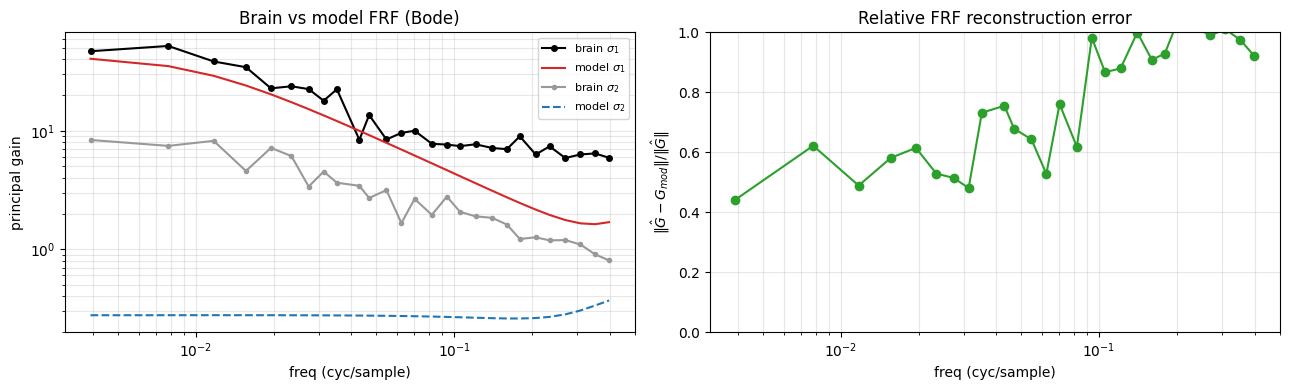

mean relative FRF error = 0.76  (lower = better model fidelity)


In [ ]:
import controller as ct   # Week-3 system ID + LinearModel

# --- probe the brain and identify an LTI model (u -> neural) ---------------- #
def record_neural(p, U):
    Y = []
    for u in U:
        Y.append(np.array(p._brain.measure())); p.next_state(np.asarray(u, float).tolist())
    return np.asarray(Y)

m = 2 # input dimensions
U_id = np.concatenate([ct.probe_inputs(400, m, seed=1, hold=h) for h in [1, 4, 16, 64]], 0)
Y_id = record_neural(plant(0), U_id)
model, _ = ct.identify_model(U_id, Y_id, 6, iters=120)
print(f"identified brain:  rho(A)={model.spectral_radius():.3f}  "
      f"ctrb={model.controllability_rank()}/{model.n}  obsv={model.observability_rank()}/{model.n}")

# --- empirical FRF via multisine (one experiment per input) ---------------- #
P, NPER, NWARM, amp = 256, 8, 2, 0.35
ks = np.unique(np.round(np.logspace(0, np.log10(0.4*P), 36)).astype(int)); ks = ks[(ks>=1)&(ks<P//2)]
fk = ks/P
Ghat = np.zeros((16, m, ks.size), complex)
for j in range(m):
    ph = np.random.default_rng(j).uniform(0, 2*np.pi, ks.size)
    t = np.arange((NPER+NWARM)*P)
    s = np.sum(np.cos(2*np.pi*np.outer(t, fk)+ph), 1)
    U = np.full((t.size, m), 0.5); U[:, j] += amp*s/np.max(np.abs(s))
    Y = record_neural(plant(0), np.clip(U, 0, 1))
    Yf = np.fft.rfft(Y[NWARM*P:].reshape(NPER, P, 16).mean(0), axis=0)
    Uf = np.fft.rfft(np.clip(U, 0, 1)[NWARM*P:].reshape(NPER, P, m).mean(0), axis=0)
    Ghat[:, j, :] = Yf[ks].T/Uf[ks, j]
Gmod = np.moveaxis(model.frequency_response(fk), 0, 2)

sig_h = np.array([np.linalg.svd(Ghat[..., i], compute_uv=False) for i in range(ks.size)])
sig_m = np.array([np.linalg.svd(Gmod[..., i], compute_uv=False) for i in range(ks.size)])
rel = np.linalg.norm(Ghat-Gmod, axis=(0, 1))/np.linalg.norm(Ghat, axis=(0, 1))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].loglog(fk, sig_h[:, 0], "ko-", ms=4, label=r"brain $\sigma_1$")
ax[0].loglog(fk, sig_m[:, 0], "C3-", label=r"model $\sigma_1$")
ax[0].loglog(fk, sig_h[:, 1], "o-", color="0.6", ms=3, label=r"brain $\sigma_2$")
ax[0].loglog(fk, sig_m[:, 1], "C0--", label=r"model $\sigma_2$")
ax[0].set(xlabel="freq (cyc/sample)", ylabel="principal gain", title="Brain vs model FRF (Bode)")
ax[0].legend(fontsize=8); ax[0].grid(which="both", alpha=0.3)
ax[1].semilogx(fk, rel, "C2o-"); ax[1].set(ylim=(0, 1), xlabel="freq (cyc/sample)",
              ylabel=r"$\|\hat G - G_{mod}\|/\|\hat G\|$", title="Relative FRF reconstruction error")
ax[1].grid(which="both", alpha=0.3); plt.tight_layout(); plt.show()
print(f"mean relative FRF error = {rel.mean():.2f}  (lower = better model fidelity)")

## 3. Closed-loop control — V1 (hand-position feedback)

Two IK joint-servos: each joint's error → a select tone at that muscle's frequency, amplitude ∝ error; the elbow (weaker, higher-frequency) gets an amplitude boost; the raised-enough bias keeps `x2` above the power threshold; inside the deadzone the tones drop and stiction holds. We plot the **distance-to-target over time** and the **hand trajectories**.

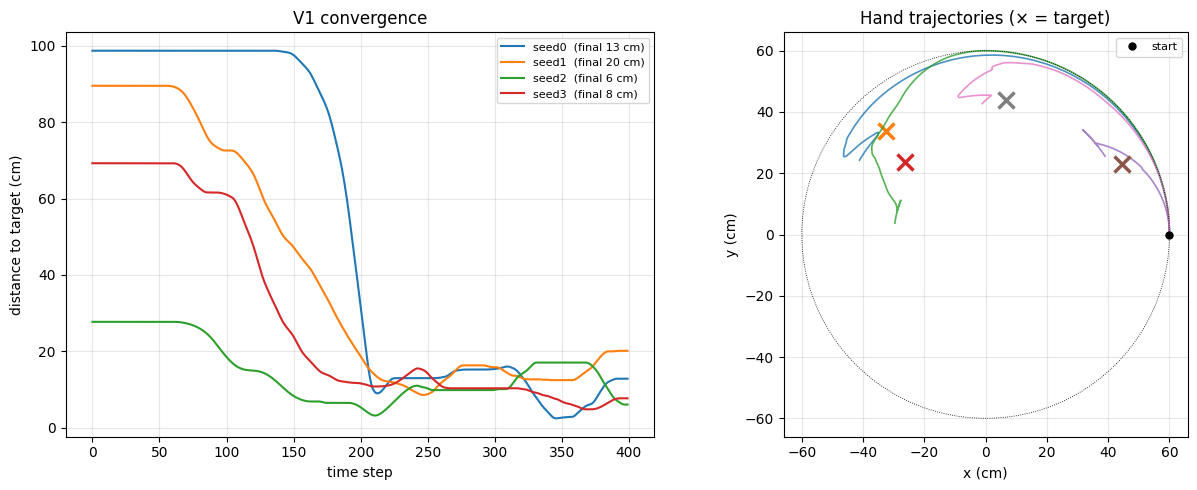

In [4]:
targets = hc.make_targets(6)
ctrl = hc.HandController(prims, mode="hand")     # V1 defaults: bias=0.5, elbow_boost=1.7

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for s in range(4):
    hand, dist = hc.run_trial(plant(s), ctrl, targets[s])
    ax[0].plot(dist, label=f"seed{s}  (final {dist[-1]:.0f} cm)")
    ax[1].plot(hand[:, 0], hand[:, 1], lw=1.2, alpha=0.8)
    ax[1].plot(*targets[s], "x", ms=11, mew=2.5)
ax[0].set(xlabel="time step", ylabel="distance to target (cm)", title="V1 convergence")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
th = np.linspace(0, 2*np.pi, 100); ax[1].plot(60*np.cos(th), 60*np.sin(th), "k:", lw=0.6)
ax[1].plot(60, 0, "ko", ms=5, label="start")
ax[1].set(xlabel="x (cm)", ylabel="y (cm)", title="Hand trajectories (× = target)", aspect="equal")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3); plt.tight_layout(); plt.show()

## 4. Evaluation over targets (official metric)

The official harness scores the **final distance to target**, averaged over independent seeds/targets. Because the plant is stochastic, we report the distribution (median is more representative than the mean, which a single failure inflates).

[2s]  final distance (cm) per trial: [22.5 23.2  9.4  4.8 11.8 36.   7.2  4.7 29.3 20.8]
  median = 16.3 cm   mean = 17.0 cm   reached <8cm: 30%   <15cm: 50%


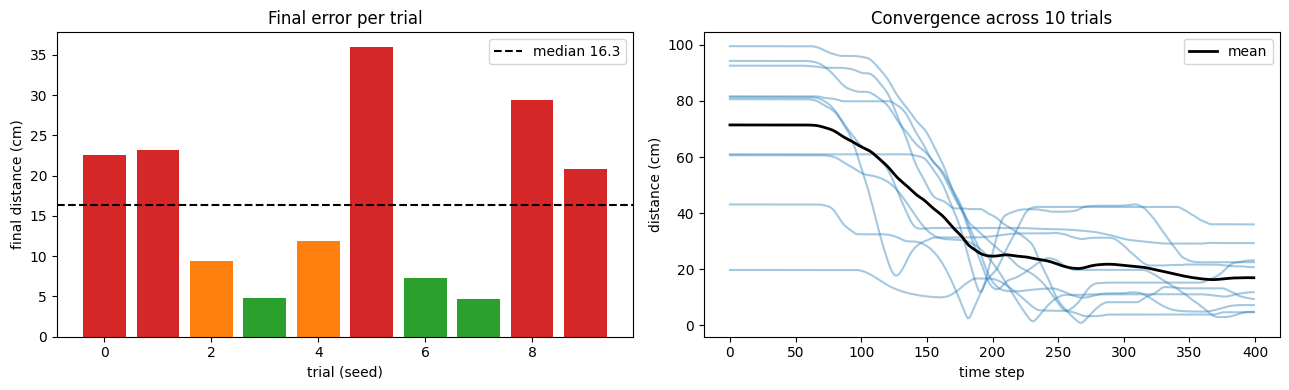

In [5]:
targets = hc.make_targets(10)
ctrl = hc.HandController(prims, mode="hand")
finals, dists = [], []
t0 = time.time()
for s in range(10):
    hand, dist = hc.run_trial(plant(s), ctrl, targets[s])
    finals.append(dist[-1]); dists.append(dist)
finals = np.array(finals)
print(f"[{time.time()-t0:.0f}s]  final distance (cm) per trial: {np.round(finals,1)}")
print(f"  median = {np.median(finals):.1f} cm   mean = {finals.mean():.1f} cm   "
      f"reached <8cm: {(finals<8).mean()*100:.0f}%   <15cm: {(finals<15).mean()*100:.0f}%")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(range(10), finals, color=["C2" if d < 8 else "C1" if d < 15 else "C3" for d in finals])
ax[0].axhline(np.median(finals), ls="--", c="k", label=f"median {np.median(finals):.1f}")
ax[0].set(xlabel="trial (seed)", ylabel="final distance (cm)", title="Final error per trial"); ax[0].legend()
for d in dists: ax[1].plot(d, color="C0", alpha=0.4)
ax[1].plot(np.mean(dists, 0), "k", lw=2, label="mean")
ax[1].set(xlabel="time step", ylabel="distance (cm)", title="Convergence across 10 trials"); ax[1].legend()
plt.tight_layout(); plt.show()

## 5. Discussion & limitations

**What works.** The select-tone joint-servo drives most targets to within a few cm. The shoulder converges easily; the elbow (higher-frequency, low-pass-attenuated muscle) needs the amplitude boost and is the main accuracy bottleneck. Power is sustained "for free" from the `x2` offset, so no power tone or DC centering is needed.

**Limitations / failure cases (honest).**
- **Stochasticity**: the ~0.25 residual neural noise occasionally stalls a muscle; feedback recovers most of the time but some trials end short.
- **Per-brain controllability**: a few random brains have a weak/near-null muscle frequency, so one joint direction is hard to drive — those targets are under-reached (the high-error trials).
- **Input budget**: with `u ∈ [0,1]` and two simultaneous tones, amplitude is shared; reaching far interior targets that need a big elbow bend is amplitude-limited.
- **IK branch** flips can momentarily mis-estimate joints near singular poses.

**Next (V2).** Replace the `current_pos` feedback with a **neural observer** (a learned, brain-invariant forward model of neural → joint velocity), so the same servo runs *without* hand sensing; comparing V1 vs V2 quantifies the value of the hand measurement.